# 04 — Model Comparison

### Objective

Compare different machine learning models for employee attrition prediction.

Models:
- Logistic Regression
- Decision Tree
- Random Forest

We will compare their performance using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../data/Employee_Attrition_Prediction.csv")

drop_cols = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=drop_cols)

X = df.drop(columns=["Attrition"])
y = df["Attrition"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1176, 30)
Test set: (294, 30)


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols)
    ]
)

## Logistic Regression

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## Decision Tree

In [6]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

## Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators = 200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

rf_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

## Predict

In [10]:
y_pred_logistic = logistic_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [11]:
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

## Metrics

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

models = {
    "Logistic Regression": (y_pred_logistic, y_prob_logistic),
    "Decision Tree": (y_pred_tree, y_prob_tree),
    "Random Forest": (y_pred_rf, y_prob_rf)
}

for name, (predictions, probabilities) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.751701,0.348837,0.638298,0.451128,0.803170
1,Decision Tree,0.755102,0.264151,0.297872,0.280000,0.569989
2,Random Forest,0.846939,0.625000,0.106383,0.181818,0.783185


In [13]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[244   3]
 [ 42   5]]


In [16]:
threshold = 0.30

y_pred_threshold = (y_prob_logistic >= threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall   :", recall_score(y_test, y_pred_threshold))
print("F1 Score :", f1_score(y_test, y_pred_threshold))

Accuracy : 0.6428571428571429
Precision: 0.2835820895522388
Recall   : 0.8085106382978723
F1 Score : 0.4198895027624309


In [17]:
from xgboost import XGBClassifier

In [18]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [19]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.8639455782312925
Precision: 0.7058823529411765
Recall   : 0.2553191489361702
F1 Score : 0.375
ROC-AUC  : 0.8104918597639763


In [20]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative class:", negative)
print("Positive class:", positive)
print("scale_pos_weight:", scale_pos_weight)

Negative class: 986
Positive class: 190
scale_pos_weight: 5.189473684210526


In [21]:
xgb_balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight
        ))
    ]
)

xgb_balanced_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [22]:
y_pred_xgb_balanced = xgb_balanced_model.predict(X_test)
y_prob_xgb_balanced = xgb_balanced_model.predict_proba(X_test)[:, 1]

In [23]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_balanced))
print("Precision:", precision_score(y_test, y_pred_xgb_balanced))
print("Recall   :", recall_score(y_test, y_pred_xgb_balanced))
print("F1 Score :", f1_score(y_test, y_pred_xgb_balanced))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb_balanced))

Accuracy : 0.8333333333333334
Precision: 0.4772727272727273
Recall   : 0.44680851063829785
F1 Score : 0.46153846153846156
ROC-AUC  : 0.7557929192867603


In [24]:
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_logistic),
        "Precision": precision_score(y_test, y_pred_logistic),
        "Recall": recall_score(y_test, y_pred_logistic),
        "F1": f1_score(y_test, y_pred_logistic),
        "ROC-AUC": roc_auc_score(y_test, y_prob_logistic)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_tree),
        "Precision": precision_score(y_test, y_pred_tree),
        "Recall": recall_score(y_test, y_pred_tree),
        "F1": f1_score(y_test, y_pred_tree),
        "ROC-AUC": roc_auc_score(y_test, y_prob_tree)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb),
        "Recall": recall_score(y_test, y_pred_xgb),
        "F1": f1_score(y_test, y_pred_xgb),
        "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
    },
    {
        "Model": "Balanced XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb_balanced),
        "Precision": precision_score(y_test, y_pred_xgb_balanced),
        "Recall": recall_score(y_test, y_pred_xgb_balanced),
        "F1": f1_score(y_test, y_pred_xgb_balanced),
        "ROC-AUC": roc_auc_score(y_test, y_prob_xgb_balanced)
    }
])

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.751701,0.348837,0.638298,0.451128,0.803170
1,Decision Tree,0.755102,0.264151,0.297872,0.280000,0.569989
2,Random Forest,0.846939,0.625000,0.106383,0.181818,0.783185
3,XGBoost,0.863946,0.705882,0.255319,0.375000,0.810492
4,Balanced XGBoost,0.833333,0.477273,0.446809,0.461538,0.755793


## Model Selection

The dataset has an imbalanced target, so accuracy alone is not sufficient
for evaluating the models.

Recall, F1-score and ROC-AUC were considered alongside accuracy and precision.

Balanced Logistic Regression currently provides the strongest recall and
ROC-AUC combination among the tested models and is selected as the leading
candidate for the final model.

Further model refinement may be considered before final deployment.

In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std ROC-AUC:", cv_scores.std())

ROC-AUC scores: [0.80648591 0.79975955 0.84317392 0.8757681  0.80870959]
Mean ROC-AUC: 0.826779415852352
Std ROC-AUC: 0.028764871271524464


In [26]:
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()

len(feature_names)

51

In [27]:
coefficients = logistic_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
42,cat__JobRole_Research Director,-1.465683,1.465683
39,cat__JobRole_Laboratory Technician,1.194333,1.194333
45,cat__JobRole_Sales Representative,1.120617,1.120617
23,cat__BusinessTravel_Non-Travel,-0.993885,0.993885
49,cat__OverTime_No,-0.892809,0.892809
33,cat__EducationField_Other,-0.798108,0.798108
24,cat__BusinessTravel_Travel_Frequently,0.787566,0.787566
50,cat__OverTime_Yes,0.761522,0.761522
29,cat__EducationField_Human Resources,0.721129,0.721129
37,cat__JobRole_Healthcare Representative,-0.647202,0.647202


## metrics after drop="first" in oneHotEncoder

In [30]:
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_logistic))

Accuracy : 0.7551020408163265
Precision: 0.3563218390804598
Recall   : 0.6595744680851063
F1 Score : 0.4626865671641791
ROC-AUC  : 0.8035145146007409


In [31]:
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = logistic_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
43,cat__OverTime_Yes,1.623568,1.623568
23,cat__BusinessTravel_Travel_Frequently,1.598904,1.598904
34,cat__JobRole_Laboratory Technician,1.569722,1.569722
40,cat__JobRole_Sales Representative,1.276684,1.276684
37,cat__JobRole_Research Director,-1.117217,1.117217
30,cat__EducationField_Other,-1.027636,1.027636
24,cat__BusinessTravel_Travel_Rarely,0.906933,0.906933
42,cat__MaritalStatus_Single,0.864752,0.864752
33,cat__JobRole_Human Resources,0.645775,0.645775
16,num__TotalWorkingYears,-0.615535,0.615535


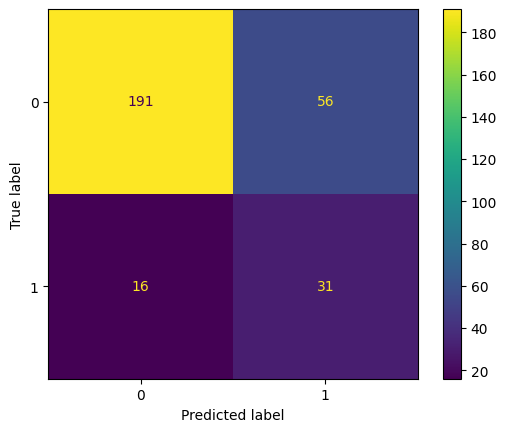

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test
)

plt.show()

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_prob = logistic_model.predict_proba(X_test)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision_score(y_test, y_pred_threshold):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred_threshold):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred_threshold):.3f}")
    print()

Threshold: 0.3
Precision: 0.284
Recall:    0.809
F1 Score:  0.420

Threshold: 0.4
Precision: 0.349
Recall:    0.809
F1 Score:  0.487

Threshold: 0.5
Precision: 0.356
Recall:    0.660
F1 Score:  0.463

Threshold: 0.6
Precision: 0.458
Recall:    0.574
F1 Score:  0.509



In [40]:
import joblib

logistic_model.fit(X_train, y_train)

joblib.dump(
    logistic_model,
    "../models/attrition_logistic_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [41]:
import joblib

loaded_model = joblib.load(
    "../models/attrition_logistic_model.pkl"
)

predictions = loaded_model.predict(X_test)

print("Model loaded successfully.")
print("Predictions generated:", len(predictions))

Model loaded successfully.
Predictions generated: 294
